# Placement Status Prediction

## Objective

The objective of this notebook is to predict whether a student will obtain a successful placement outcome.

Target Variable:
- placement_status

Features:
- study_hours
- attendance
- sleep_hours
- internet_usage
- assignments_completed
- previous_score

The following classification models will be evaluated:

1. Logistic Regression
2. Random Forest Classifier

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Special attention will be paid to Recall and F1 Score due to class imbalance within the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("../data/student_dataset_10000_rows.csv")

df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [3]:
le = LabelEncoder()

df["placement_status"] = le.fit_transform(
    df["placement_status"]
)

In [4]:
dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
)

{'Not Placed': np.int64(0), 'Placed': np.int64(1)}

In [5]:
df["placement_status"].value_counts()

placement_status
1    8356
0    1644
Name: count, dtype: int64

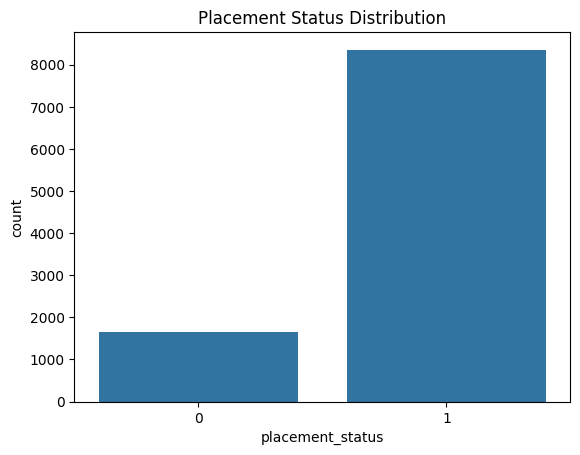

In [6]:
sns.countplot(
    data=df,
    x="placement_status"
)

plt.title("Placement Status Distribution")
plt.show()

The dataset is imbalanced.

Approximately 84% of students belong to the Placed class.

Because of this imbalance, accuracy alone may not provide a reliable assessment of model quality.

In [7]:
X = df[
    [
        "study_hours",
        "attendance",
        "sleep_hours",
        "internet_usage",
        "assignments_completed",
        "previous_score"
    ]
]

y = df["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

stratify=y

## Logistic Regression

Logistic Regression serves as a baseline classification model.

In [8]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [9]:
lr_accuracy = accuracy_score(
    y_test,
    lr_preds
)

lr_precision = precision_score(
    y_test,
    lr_preds
)

lr_recall = recall_score(
    y_test,
    lr_preds
)

lr_f1 = f1_score(
    y_test,
    lr_preds
)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1:", lr_f1)

Accuracy: 0.9065
Precision: 0.9308943089430894
Recall: 0.9593058049072412
F1: 0.9448865310934277


## Random Forest Classifier

Random Forest can capture nonlinear relationships between academic variables and placement outcomes.

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [11]:
rf_accuracy = accuracy_score(
    y_test,
    rf_preds
)

rf_precision = precision_score(
    y_test,
    rf_preds
)

rf_recall = recall_score(
    y_test,
    rf_preds
)

rf_f1 = f1_score(
    y_test,
    rf_preds
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)

Accuracy: 0.8915
Precision: 0.9149543378995434
Recall: 0.9593058049072412
F1: 0.9366053169734151


In [12]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1": [
        lr_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.9065,0.930894,0.959306,0.944887
1,Random Forest,0.8915,0.914954,0.959306,0.936605


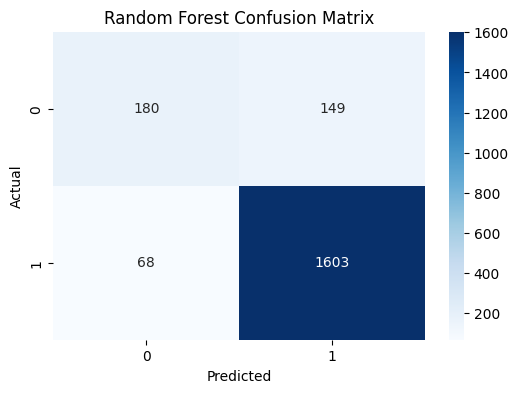

In [13]:
cm = confusion_matrix(
    y_test,
    rf_preds
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
print(
    classification_report(
        y_test,
        rf_preds
    )
)

              precision    recall  f1-score   support

           0       0.73      0.55      0.62       329
           1       0.91      0.96      0.94      1671

    accuracy                           0.89      2000
   macro avg       0.82      0.75      0.78      2000
weighted avg       0.88      0.89      0.89      2000



In [15]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
0,study_hours,0.256237
4,assignments_completed,0.198583
5,previous_score,0.194981
1,attendance,0.170573
3,internet_usage,0.100593
2,sleep_hours,0.079033


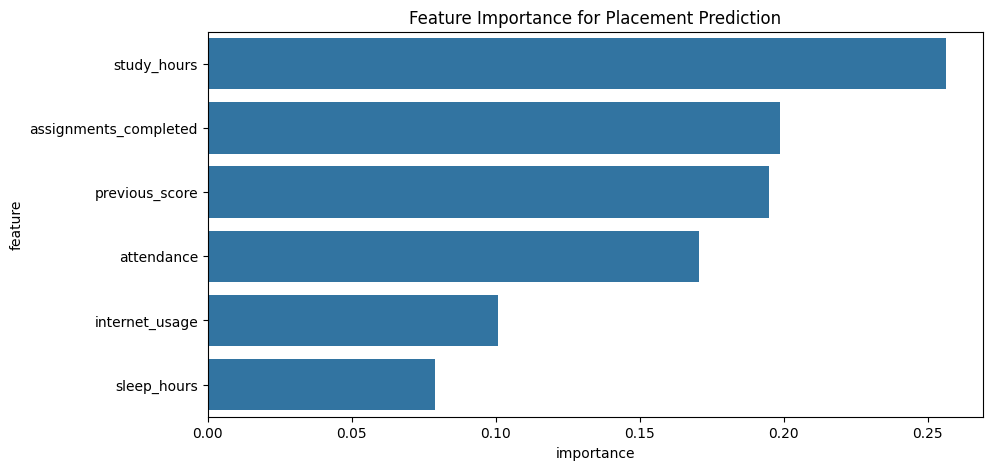

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title(
    "Feature Importance for Placement Prediction"
)

plt.show()

In [17]:
majority_class_accuracy = (
    df["placement_status"]
    .value_counts(normalize=True)
    .max()
)

print(majority_class_accuracy)

0.8356


## Baseline Performance

Because 83.6% of students belong to the Placed class, a naive model that predicts "Placed" for every student would achieve approximately 83.6% accuracy.

Therefore, model performance should be compared against this baseline rather than evaluated using accuracy alone.

<Axes: xlabel='placement_status', ylabel='exam_score'>

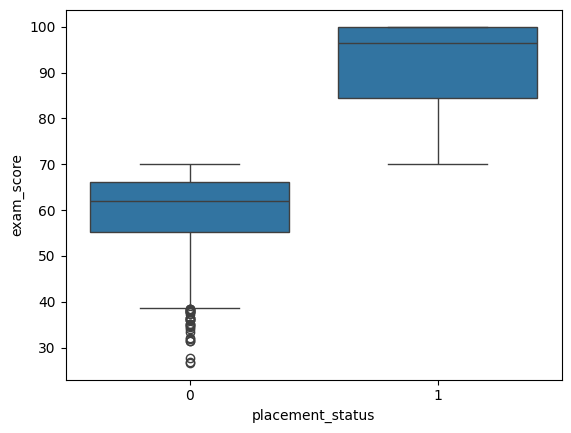

In [19]:
sns.boxplot(
    data=df,
    x="placement_status",
    y="exam_score"
)

### Relationship Between Exam Score and Placement Status

A clear separation exists between the two classes.

Students classified as Not Placed have exam scores below approximately 70, while students classified as Placed have scores above approximately 70.

This suggests that placement status is strongly dependent on examination performance and may have been generated using a score threshold.

# Findings

## Model Performance

The Logistic Regression model achieved the strongest overall performance.

| Model | Accuracy | Precision | Recall | F1 |
|---------|---------|---------|---------|---------|
| Logistic Regression | 90.7% | 93.1% | 95.9% | 94.5% |
| Random Forest | 89.2% | 91.5% | 95.9% | 93.7% |

Both models substantially outperformed the naive baseline accuracy of 83.6%.

## Key Predictors of Placement Success

The most influential variables were:

1. Study Hours
2. Assignments Completed
3. Previous Score
4. Attendance

These findings suggest that consistent academic engagement is strongly associated with successful placement outcomes.

## Academic Patterns

Students who dedicate more time to studying, complete assignments consistently, and maintain stronger historical academic performance are significantly more likely to achieve placement success.

Internet usage exhibited a modest negative relationship with placement outcomes, while sleep hours contributed relatively little predictive power.

## Business Implications

Educational institutions could leverage these variables to identify students with lower placement probabilities and provide targeted academic support before placement evaluations occur.